In [1]:
import pandas as pd
import numpy as np

In [2]:
from showz_marketing.data_prep import load_visits, load_costs, load_orders, summarize_df

In [3]:
visitas = load_visits('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/raw/visits_log_us.csv', '/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/visits_clean.csv')
ordenes = load_orders('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/raw/orders_log_us.csv', '/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/orders_clean.csv')
costos = load_costs('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/raw/costs_us.csv', '/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/costs_clean.csv')

Archivo limpio guardado como: /Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/visits_clean.csv
Archivo limpio guardado como: /Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/orders_clean.csv
Archivo limpio guardado como: /Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/interim/costs_clean.csv


In [4]:
summarize_df(visitas, 'visitas')


== Resumen: visitas ==
Shape: (359400, 5)
Dtypes:
 Device               object
End Ts       datetime64[ns]
Source Id             Int64
Start Ts     datetime64[ns]
Uid                  uint64
dtype: object
Duplicados: 0
Nulos por columna:
 Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64


# Visitas

In [5]:
visitas.columns = [ columna.lower().replace(' ', '_') for columna in visitas.columns]

## DAU, MAU y WAU

Estas son conocidas como métricas de fidelidad, vitales para construir un negocio sostenible. Permiten determinar la frecuencia con la que los usuarios usan o visitan una aplicación, página web o producto y su deseo de volver.

* DAU: Usuarios activos or día
* MAU: Usuarios activos mensuales
* WAU: Usuarios activos semanales

In [6]:
visitas['sesion_mes'] = visitas['start_ts'].dt.strftime('%Y - %m - 01')
visitas['sesion_semana'] = visitas['start_ts'].dt.isocalendar().week
visitas['sesion_fecha'] = visitas['start_ts'].dt.date

In [7]:
dau = visitas.groupby('sesion_fecha').agg({'uid': 'nunique'})
wau = visitas.groupby('sesion_semana').agg({'uid': 'nunique'})
mau = visitas.groupby('sesion_mes').agg({'uid': 'nunique'})

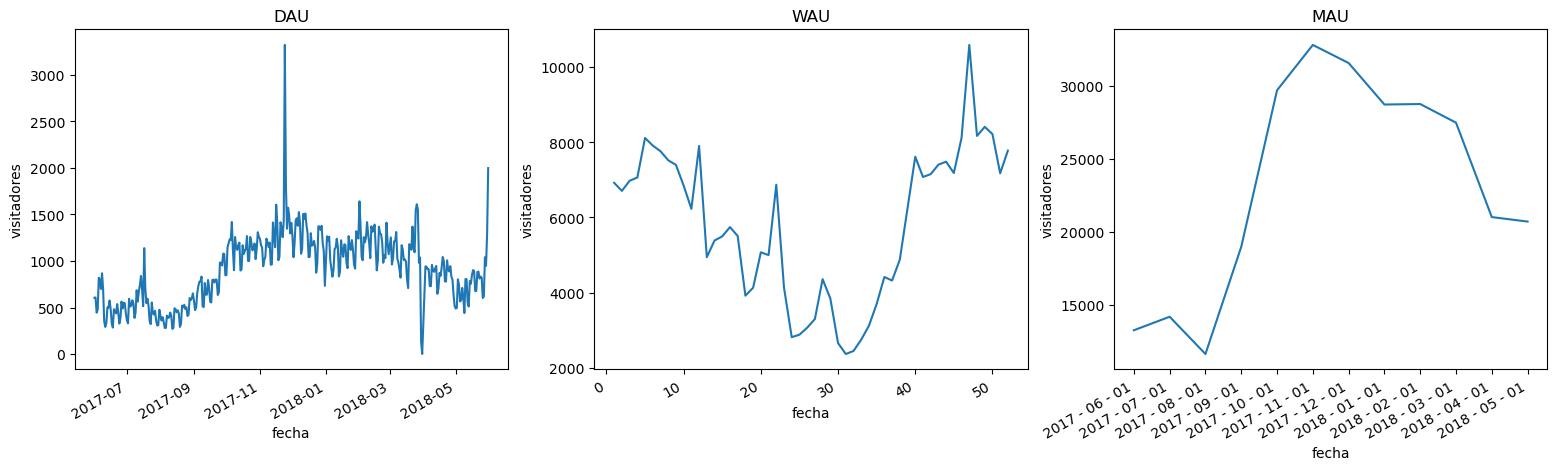

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(19,5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='fecha', ylabel='visitadores')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='fecha', ylabel='visitadores')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='fecha', ylabel='visitadores')
fig.autofmt_xdate(rotation=30)
plt.show()

In [9]:
fig.savefig('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/reports/figures/daumauwau.png', bbox_inches='tight')

En el gráfico **DAU**, parece haber un aumento gradual en los usuarios activos diarios a lo largo del tiempo, con una gran subida hacia mediados de 2018. La gráfica de **WAU** muestra un pico en las últimas semana del año, esto refleja el comportamiento de compra de los usuarios en fechas festivas como Navidad y fin de año. Por último, la gráfica **MAU** muestra un despunte en noviembre de 2017 y una caída después de esto, nuevamente, relacionado a las épocas festivas de los últimos meses del año.

## Sesiones por día

El número de sesiones por día indica cuántas veces los usuarios interactúan con la plataforma, lo que proporciona información valiosa sobre la fidelidad y el interés continuo de los usuarios.

Si los usuarios realizan múltiples sesiones en un día, puede indicar un alto nivel de interés o un comportamiento específico.

In [10]:
sesiones_por_usuario = visitas.groupby('sesion_fecha').agg({'uid': ['count', 'nunique']})

In [11]:
sesiones_por_usuario.columns = ['n_sesiones', 'n_usuarios']

In [12]:
sesiones_por_usuario['sesiones_por_usuario'] = sesiones_por_usuario['n_sesiones']/sesiones_por_usuario['n_usuarios']

In [13]:
sesiones_por_usuario

,n_sesiones,n_usuarios,sesiones_por_usuario
sesion_fecha,,,
2017-06-01,664,605,1.097521
2017-06-02,658,608,1.082237
2017-06-03,477,445,1.071910
2017-06-04,510,476,1.071429
2017-06-05,893,820,1.089024
...,...,...,...
2018-05-27,672,620,1.083871
2018-05-28,1156,1039,1.112608
2018-05-29,1035,948,1.091772


<Axes: xlabel='sesion_fecha'>

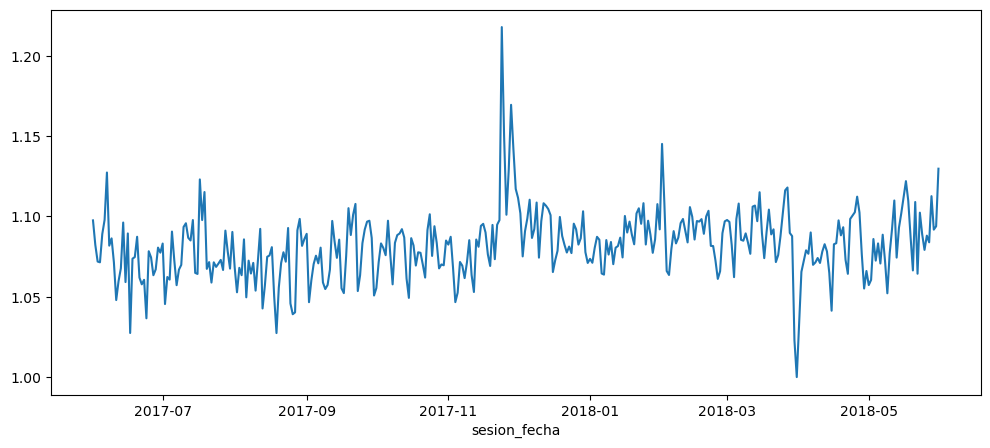

In [14]:
plt.figure(figsize=(12,5))
sesiones_por_usuario['sesiones_por_usuario'].plot()

In [15]:
plt.savefig('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/reports/figures/sesiones_usuario.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Duración de las sesiones

La duración de las sesiones es un indicador directo del nivel de interacción y compromiso de los usuarios con la plataforma. Entender la duración de las sesiones ayuda a identificar áreas para mejorar la retención de usuarios, la optimización de la interfaz y aumentar la interacción con el contenido.

In [16]:
visitas['duracion_sesion_seg'] = (visitas['end_ts'] - visitas['start_ts']).dt.seconds

In [17]:
visitas

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017 - 12 - 01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018 - 02 - 01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017 - 07 - 01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018 - 05 - 01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017 - 12 - 01,52,2017-12-27,0
...,...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017 - 07 - 01,30,2017-07-29,19
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018 - 01 - 01,4,2018-01-25,19
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018 - 03 - 01,9,2018-03-03,19
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017 - 11 - 01,44,2017-11-02,19


## Con qué frecuencia regresan los usarios (nivel de retención)?

Este análisis es crucial para la optimización de la retención de usuarios y la creación de estrategias de fidelización, además de ayudar a identificar la efectividad de las campañas y la calidad de la experiencia de usuario.

In [18]:
primeras_visitas = visitas.groupby('uid').agg({'start_ts': 'min'}).reset_index()

In [19]:
primeras_visitas.columns = ['uid', 'inicio_primera_sesion_ts']

In [20]:
primeras_visitas['primera_sesion_fecha'] = primeras_visitas['inicio_primera_sesion_ts'].dt.date
primeras_visitas['primera_sesion_mes'] = pd.to_datetime(primeras_visitas['inicio_primera_sesion_ts'].dt.strftime('%Y-%m-01'))

In [21]:
visitas_full = pd.merge(primeras_visitas, visitas, on = 'uid', how='inner')

In [22]:
visitas_full['sesion_mes'] = pd.to_datetime(visitas_full['sesion_mes'])
visitas_full['primera_sesion_mes'] = pd.to_datetime(visitas_full['primera_sesion_mes'])

visitas_full['edad_meses'] = ((visitas_full['sesion_mes'] - visitas_full['primera_sesion_mes']) / (30 * np.timedelta64(1, 'D'))).round().astype('int')

In [23]:
cohortes_visitas = visitas_full.pivot_table(
    index='primera_sesion_mes',
    columns='edad_meses',
    values='uid',
    aggfunc='nunique'
)

In [24]:
cohortes_visitas.fillna(0, inplace=True)

### Análisis de cohortes

Una cohorte es un grupo de individuos que comparten una característica o experiencia común, como la fecha de inicio, el año de nacimiento o un evento específico. El análisis de cohortes permite observar el comportamiento de estos grupos a lo largo del tiempo, identificando patrones y tendencias que podrían ser difíciles de observar en un análisis individual. 

In [25]:
cohortes_visitas

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_sesion_mes,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,0.0
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,0.0,0.0
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,0.0,0.0,0.0
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,0.0,0.0,0.0,0.0
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,0.0,0.0,0.0,0.0,0.0
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-01,22197.0,1267.0,565.0,446.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
retencion = pd.DataFrame()

In [27]:
for col in cohortes_visitas.columns:
    retencion = pd.concat([retencion, cohortes_visitas[col]/cohortes_visitas[0]], axis = 1)

In [28]:
retencion.columns = cohortes_visitas.columns

In [29]:
retencion.index = [str(indice)[:10] for indice in retencion.index]

[Text(0.5, 1.0, 'Ratio de retencion')]

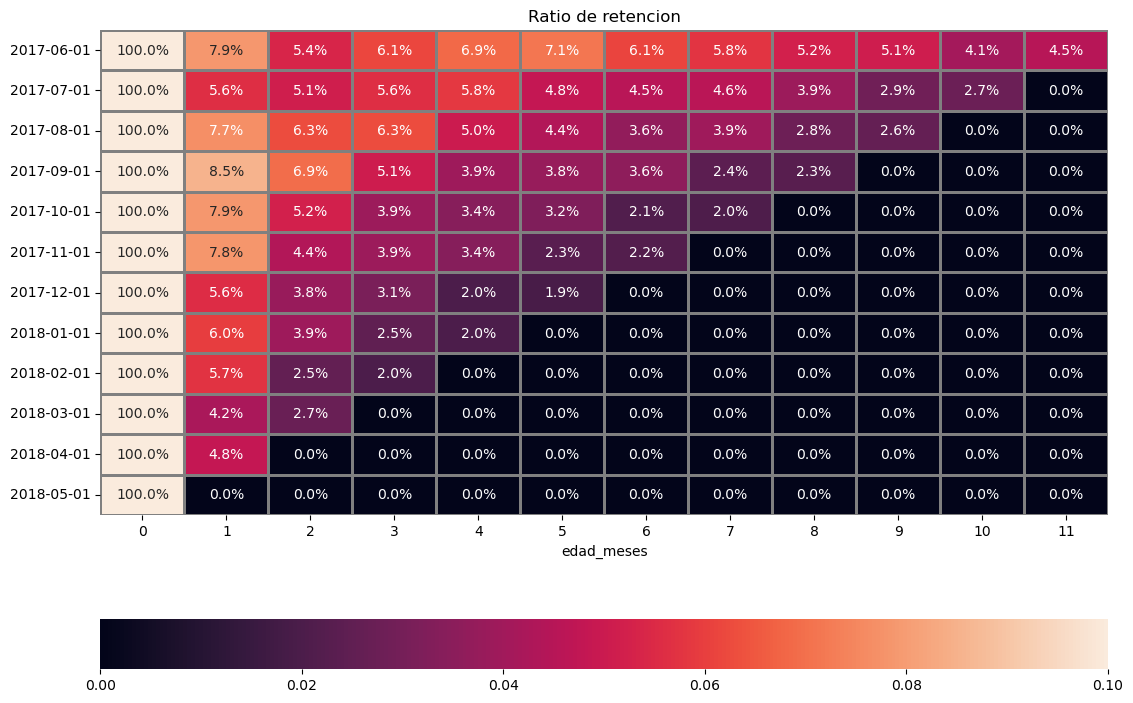

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(13,9))

sns.heatmap(
    retencion,
    annot=True,
    fmt='.1%',
    linewidths=1,
    linecolor='grey',
    vmax=0.1,
    cbar_kws={'orientation': 'horizontal'}
).set(title = 'Ratio de retencion')

In [31]:
plt.savefig('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/reports/figures/heatmap_retencion.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Órdenes/Ventas

In [32]:
summarize_df(ordenes, 'ordenes')


== Resumen: ordenes ==
Shape: (50415, 3)
Dtypes:
 Buy Ts     datetime64[ns]
Revenue           float64
Uid                uint64
dtype: object
Duplicados: 0
Nulos por columna:
 Buy Ts     0
Revenue    0
Uid        0
dtype: int64


In [33]:
ordenes.columns = [ columna.lower().replace(' ', '_') for columna in ordenes.columns]

In [34]:
ordenes

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247


In [35]:
visitas

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017 - 12 - 01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018 - 02 - 01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017 - 07 - 01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018 - 05 - 01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017 - 12 - 01,52,2017-12-27,0
...,...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017 - 07 - 01,30,2017-07-29,19
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018 - 01 - 01,4,2018-01-25,19
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018 - 03 - 01,9,2018-03-03,19
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017 - 11 - 01,44,2017-11-02,19


## Cuándo empieza la gente a comprar?

Este cálculo ayuda a entender cuánto tiempo tardan los usuarios en tomar la decisión de compra después de registrarse o interactuar con el sitio.

In [36]:
ordenes['compra_mes'] = pd.to_datetime(ordenes['buy_ts'].dt.strftime('%Y-%m-01'))

In [37]:
primeras_compras = ordenes.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

In [38]:
primeras_compras.columns = ['uid', 'primera_compra']

In [39]:
primeras_compras['primera_compra_fecha'] = primeras_compras['primera_compra'].dt.date

In [40]:
primeras_compras['primera_compra_mes'] = pd.to_datetime(primeras_compras['primera_compra'].dt.strftime('%Y-%m-01'))

In [41]:
compradores = pd.merge(primeras_visitas, primeras_compras, on = 'uid')

In [42]:
compradores

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes,primera_compra,primera_compra_fecha,primera_compra_mes
0,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,2018-01-03 21:51:00,2018-01-03,2018-01-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06-01,2017-06-03 10:13:00,2017-06-03,2017-06-01
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,2017-10-01,2017-10-11 18:33:00,2017-10-11,2017-10-01
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,2018-01-01,2018-01-28 15:54:00,2018-01-28,2018-01-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11-01,2017-11-24 10:14:00,2017-11-24,2017-11-01
...,...,...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-08-20,2017-08-01,2017-11-24 09:03:00,2017-11-24,2017-11-01
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22,2017-09-01,2017-09-22 23:55:00,2017-09-22,2017-09-01
36520,18445601152732270159,2017-08-07 11:51:00,2017-08-07,2017-08-01,2018-03-26 22:54:00,2018-03-26,2018-03-01
36521,18446156210226471712,2017-11-07 10:01:00,2017-11-07,2017-11-01,2018-02-18 19:34:00,2018-02-18,2018-02-01


### Tiempo transcurrido desde la primera visita a la primera compra

In [43]:
compradores['dias_hasta_la_primera_compra'] = ((compradores['primera_compra'] - compradores['inicio_primera_sesion_ts']) / np.timedelta64(1, 'D')).astype('int')

In [44]:
compradores['dias_hasta_la_primera_compra']

0        106
1          0
2          0
3          0
4          0
        ... 
36518     95
36519      0
36520    231
36521    103
36522      0
Name: dias_hasta_la_primera_compra, Length: 36523, dtype: int64

In [45]:
import plotly.express as px

px.histogram(compradores['dias_hasta_la_primera_compra'])

## Cuántos pedidos hacen durante un periodo de tiempo determinado?

Esta información ayuda a la empresa a predecir la demanda futura y a planificar mejor la gestión del negocio; además, esta métrica puede ayudar a identificar segmentos de clientes más rentables, que realicen más pedidos, lo que facilita la toma de decisiones sobre estrategias de fidelización.

In [46]:
tamano_cohorte = compradores.groupby('primera_compra_mes').agg({'uid': 'nunique'}).reset_index()

In [47]:
tamano_cohorte.columns = ['primera_compra_mes', 'n_compradores']

In [48]:
cohortes = pd.merge(ordenes, compradores, how='inner', on='uid')

In [49]:
cohortes = cohortes.groupby(['primera_compra_mes', 'compra_mes']).agg({'uid':'count', 'revenue': 'sum'}).reset_index()

In [50]:
cohortes['edad_meses'] = ((cohortes['compra_mes'] - cohortes['primera_compra_mes'])/(30*np.timedelta64(1, 'D'))).round().astype('int')

In [51]:
cohortes.columns = ['primera_compra_mes', 'compra_mes', 'n_ordenes', 'venta_total', 'edad_meses']

In [52]:
cohortes

,primera_compra_mes,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2017-06-01,2354,9557.49,0
1,2017-06-01,2017-07-01,177,981.82,1
2,2017-06-01,2017-08-01,174,885.34,2
3,2017-06-01,2017-09-01,226,1931.30,3
4,2017-06-01,2017-10-01,292,2068.58,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,176,1114.87,2
75,2018-04-01,2018-04-01,2495,10600.69,0
76,2018-04-01,2018-05-01,195,1209.92,1
77,2018-05-01,2018-05-01,3249,13925.76,0


## Ticket promedio

El ticket promedio (el valor promedio de cada compra) es una métrica que indica el valor que los clientes están dispuestos a gastar por transacción.

In [53]:
reporte_cohortes = pd.merge(tamano_cohorte, cohortes, how='inner', on='primera_compra_mes')

In [54]:
reporte_cohortes['ordenes_por_comprador'] = reporte_cohortes['n_ordenes'] / reporte_cohortes['n_compradores']

In [55]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses,ordenes_por_comprador
0,2017-06-01,2023,2017-06-01,2354,9557.49,0,1.163618
1,2017-06-01,2023,2017-07-01,177,981.82,1,0.087494
2,2017-06-01,2023,2017-08-01,174,885.34,2,0.086011
3,2017-06-01,2023,2017-09-01,226,1931.30,3,0.111715
4,2017-06-01,2023,2017-10-01,292,2068.58,4,0.144340
...,...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2,0.049816
75,2018-04-01,2276,2018-04-01,2495,10600.69,0,1.096221
76,2018-04-01,2276,2018-05-01,195,1209.92,1,0.085677
77,2018-05-01,2988,2018-05-01,3249,13925.76,0,1.087349


In [56]:
# Calcula el ticket promedio por usuario (venta total / número de compradores)
ticket_promedio_usuario = reporte_cohortes['venta_total'] / reporte_cohortes['n_compradores']

# Imprime el ticket promedio por usuario
print(ticket_promedio_usuario)


0     4.724414
1     0.485329
2     0.437637
3     0.954671
4     1.022531
        ...   
74    0.315559
75    4.657597
76    0.531599
77    4.660562
78    3.420000
Length: 79, dtype: float64


## Lifetime Value por cohorte

El Lifetime Value (LTV) evalúa la rentabilidad a largo plazo de los clientes. Mide cuánto ingreso neto se puede esperar de un cliente a lo largo de su relación con la empresa. Permite entendr la rentabilidad de los clientes a largo plazo.

In [57]:
ordenes

,buy_ts,revenue,uid,compra_mes
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01
...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-01
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-01
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-01
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-01


In [58]:
cohortes_ltv_1 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ordenes_por_comprador',
    aggfunc='sum'
)

In [59]:
cohortes_ltv_1.round(2).fillna(0, inplace=True)

In [60]:
cohortes_ltv_1

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,1.163618,0.087494,0.086011,0.111715,0.144340,0.107761,0.136431,0.086011,0.104795,0.075630,0.047454,0.042511
2017-07-01,1.136765,0.052002,0.062402,0.054082,0.037441,0.042642,0.031721,0.026001,0.030161,0.012480,0.027561,NaN
2017-08-01,1.118978,0.078832,0.072993,0.059124,0.062044,0.045255,0.035766,0.056934,0.033577,0.033577,NaN,NaN
2017-09-01,1.136381,0.084851,0.062379,0.063541,0.025959,0.042232,0.041844,0.021697,0.023634,NaN,NaN,NaN
2017-10-01,1.143779,0.072350,0.037327,0.028111,0.029724,0.023733,0.019816,0.028802,NaN,NaN,NaN,NaN
2017-11-01,1.179368,0.097280,0.044597,0.051703,0.033325,0.014457,0.024994,NaN,NaN,NaN,NaN,NaN
2017-12-01,1.152635,0.061602,0.046087,0.040840,0.019621,0.023956,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,1.121554,0.066410,0.047139,0.018974,0.023125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,1.121611,0.060805,0.022733,0.019173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
reporte_cohortes['ltv'] = reporte_cohortes['venta_total'] / reporte_cohortes['n_compradores']

In [62]:
cohortes_ltv_2 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ltv',
    aggfunc='sum'
)

In [63]:
cohortes_ltv_2

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,4.724414,0.485329,0.437637,0.954671,1.022531,0.735502,0.950440,0.581592,0.553213,0.605788,0.571261,0.256856
2017-07-01,6.010218,0.335211,0.623531,0.358976,0.176791,0.156048,0.120208,0.141820,0.161232,0.147145,0.155673,NaN
2017-08-01,5.276518,0.471993,0.458482,0.391277,0.494051,0.283540,0.210664,0.405007,0.292212,0.187978,NaN,NaN
2017-09-01,5.644529,1.117586,0.520930,3.975792,0.400558,0.647067,0.701608,0.243150,0.184006,NaN,NaN,NaN
2017-10-01,5.003733,0.535763,0.191394,0.157145,0.151560,0.120362,0.084816,0.115470,NaN,NaN,NaN,NaN
2017-11-01,5.154683,0.399233,0.199556,0.324952,0.148013,0.053879,0.114928,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.738191,0.260374,0.925097,1.065275,0.312930,0.338047,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,4.135636,0.294758,0.304281,0.142778,0.062698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,4.156987,0.278274,0.078515,0.074144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Para los usuarios que hicieron su primera compra en junio de 2017, el ticket promedio de compra para el primer mes (edad_meses = 0) es 1.16.
A medida que avanzan los meses, la cantidad de órdenes por comprador disminuye gradualmente. Esto es una señal común en muchos negocios en línea, ya que algunos usuarios tienden a hacer menos compras a medida que pasa el tiempo.

# Marketing

In [64]:
summarize_df(costos, 'costos')


== Resumen: costos ==
Shape: (2542, 3)
Dtypes:
 Source_Id             Int64
Dt           datetime64[ns]
Costs               float64
dtype: object
Duplicados: 0
Nulos por columna:
 Source_Id    0
Dt           0
Costs        0
dtype: int64


In [65]:
costos.columns = [ columna.lower().replace(' ', '_') for columna in costos.columns]

In [66]:
# Agrupamos por la fuente y el periodo (por ejemplo, mes) para calcular los gastos
costos['month'] = costos['dt'].dt.to_period('M')

# Gastos totales por mes
gastos_totales = costos.groupby('month')['costs'].sum()

# Gastos por fuente por mes
gastos_por_fuente = costos.groupby(['month', 'source_id'])['costs'].sum()


In [67]:
gastos_totales

month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64

In [68]:
gastos_por_fuente

month    source_id
2017-06  1            1125.61
         2            2427.38
         3            7731.65
         4            3514.80
         5            2616.12
                       ...   
2018-05  3            9411.42
         4            4214.21
         5            3669.56
         9             362.17
         10            409.86
Name: costs, Length: 84, dtype: float64

## CAC de cada uno de los clientes

In [69]:
# Para cada fuente, calculamos el número de usuarios únicos que hicieron al menos una compra
clientes_por_fuente = visitas.groupby('source_id')['uid'].nunique()

# Calculamos el CAC por fuente (gastos / número de clientes)
cac_por_fuente = gastos_por_fuente / clientes_por_fuente

print(cac_por_fuente)

month    source_id
2017-06  1            0.059246
         2            0.092489
         3            0.103425
         4            0.042081
         5            0.045918
                        ...   
2018-05  3            0.125895
         4            0.050454
         5            0.064408
         9            0.039094
         10           0.050807
Length: 84, dtype: float64


## ROMI

In [70]:
ordenes

,buy_ts,revenue,uid,compra_mes
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01
...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-01
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-01
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-01
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-01


In [71]:
# Relacionamos las órdenes con las visitas
ordenes_con_visitas = pd.merge(ordenes, visitas[['uid', 'source_id']], on='uid', how='left')

# Ahora calculamos los ingresos por cada fuente
ingresos_por_fuente = ordenes_con_visitas.groupby('source_id')['revenue'].sum()

In [72]:
# ROMI por fuente
romi_por_fuente = (ingresos_por_fuente - gastos_por_fuente) / gastos_por_fuente


In [73]:
# Crear una nueva columna para agrupar las fechas por mes
ordenes_con_visitas['month'] = ordenes['buy_ts'].dt.to_period('M')

# Calcular los ingresos por fuente y mes
ingresos_por_mes_fuente = ordenes_con_visitas.groupby(['month', 'source_id'])['revenue'].sum()

costos_por_mes_fuente = costos.groupby(['month', 'source_id'])['costs'].sum()

# Calcular el ROMI temporal por fuente y mes
romi_temporal = (ingresos_por_mes_fuente - costos_por_mes_fuente) / costos_por_mes_fuente


In [74]:
romi_por_fuente

month    source_id
2017-06  1            2040.737520
         2            1085.846398
         3              37.373175
         4             140.313921
         5             450.614276
                         ...     
2018-05  3              30.524250
         4             116.860802
         5             320.966977
         9              99.345832
         10             34.668838
Length: 84, dtype: float64

In [75]:
romi_temporal

month    source_id
2017-06  1            1.787768
         2           -0.179024
         3           -0.932970
         4           -0.714260
         5           -0.002148
                        ...   
2018-05  4           -0.229799
         5            0.590553
         9            0.065991
         10          -0.694749
2018-06  2                 NaN
Length: 85, dtype: float64

In [76]:
ordenes.to_csv('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/processed/orders_processed.csv', index=False)
visitas.to_csv('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/processed/visits_processed.csv', index=False)
costos.to_csv('/Users/melaniealvarez/Documents/Octavo semestres/Data Mining/Analisis de Cohortes/Alvarez-Pset4/data/processed/costs_processed.csv', index=False)

# Conclusiones

* El CAC varía considerablemente entre las diferentes fuentes. Por ejemplo, la fuente 3 tiene un CAC relativamente alto (0.103425 en junio de 2017), mientras que otras fuentes, como la fuente 4, tienen CAC más bajo (0.042081 en junio de 2017). El ROMI por fuente muestra valores tanto positivos como negativos. En junio de 2017, fuente 1 tiene un ROMI de 1.787768, indicando un retorno positivo, mientras que fuente 2 muestra un ROMI negativo de -0.179024.

* Las fuentes con un ROMI positivo indican que están generando un retorno favorable en comparación con la inversión realizada. En particular, la fuente 1 ha tenido un buen desempeño a lo largo del tiempo. Las fuentes con un alto CAC y un ROMI negativo pueden requerir una revisión y ajuste de la inversión. Podría ser útil redirigir el presupuesto hacia fuentes más rentables.

* Las cohortes con valores más altos en los primeros meses pueden tener un potencial de monetización más alto si se utilizan estrategias de retención y fidelización para evitar que los usuarios caigan en la deserción. Se podría optimizar las campañas de retención para las cohortes más jóvenes y evaluar los estrategias de adquisición de usuarios para asegurar que los nuevos usuarios se conviertan en compradores frecuentes.

* El presupuesto total se debe basar en métricas como el retorno esperado y el LTV de cada cohorte, ya que se quiere maximizar el retorno sobre la inversión (ROI). La decisión también debe estar basada en los ingresos actuales y la capacidad financiera para invertir en marketing. A mayor LTV, mayor será la inversión que se debe hacer en esa cohorte y las fuentes que generen un alto ROMI deben ser priorizadas, ya que generarán un mayor retorno sobre cada dólar invertido. Según lo obtenido, las fuentes 1, 2 y 3 son las principales fuentes de adquisición, siendo la fuente 1 la de mayor rentabilidad. Se sugiere invertir el 50% en esta, 30 en la fuente dos y 20 en la fuente tres.

* Es importante el ,onitoreo constante de cada fuente y ajustar el presupuesto en función de los resultados. Las campañas de re-targeting o remarketing deben ser parte de la estrategia de inversión, ya que suelen ser más económicas y tienen un ROMI más alto. Se observaron ciertos picos de demanda en algunos meses, por lo que se debe considerar un aumento temporal del presupuesto en las fuentes que más efectivas han sido en esos períodos.